In [1]:
import torch
import numpy as np
import matplotlib.pyplot as plt

In [2]:
dim128_path = 'runs/base/exp1/model_weights.pth'
dim64_path = 'runs/base/exp3/model_weights.pth'
weights128 = torch.load(dim128_path)
weights64 = torch.load(dim64_path)

In [3]:
def visualize_features(weights, n=1000):
    features = []
    for key, value in weights.items():
        if 'readout' in key and 'feature' in key:
            features.append(value.cpu().squeeze().permute(1, 0))

    features = torch.cat(features)

    idcs = np.random.choice(features.shape[0], n)
    features = features[idcs]
    #features = (
    #    features - features.mean(axis=0)
    #) / features.std(axis=0)

    dists = (
        (features[None, :, :] - features[:, None, :])
        .pow(2)
        .sum(axis=-1)
        .sqrt()
    )
    i, j = np.tril_indices(n, k=-1)
    unique_dists = dists[i, j]

    plt.hist(unique_dists, bins=100, histtype='step', label=f'{features.shape[1]} dim embeddings', density=True)
    plt.xlabel('distance')
    plt.ylabel('density')
    print(f'std on {features.shape[1]}-dimensional features: {unique_dists.std()}')

std on 64-dimensional features: 0.19836550951004028
std on 128-dimensional features: 0.19708013534545898


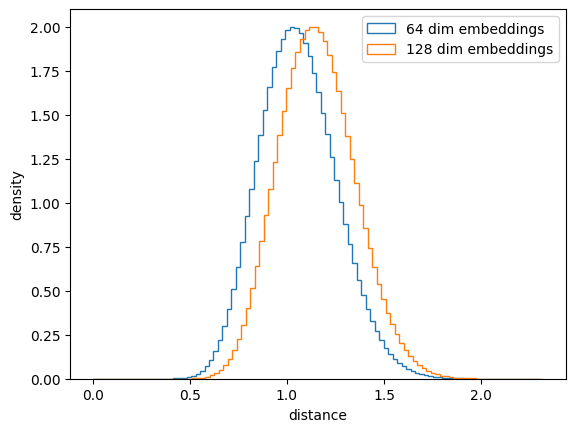

In [4]:
visualize_features(weights64, n=10000)
visualize_features(weights128, n=10000)
#plt.xlim(0, 50)
plt.legend()
plt.savefig('plots/embedding_distances.png')
plt.show()

In [5]:
features128 = []
for key, value in weights128.items():
    if 'readout' in key and 'feature' in key:
        features128.append(value.cpu().squeeze().permute(1, 0))
features128 = torch.cat(features128)

features64 = []
for key, value in weights64.items():
    if 'readout' in key and 'feature' in key:
        features64.append(value.cpu().squeeze().permute(1, 0))
features64 = torch.cat(features64)


In [7]:
np.linalg.norm?

Signature:       np.linalg.norm(x, ord=None, axis=None, keepdims=False)
Call signature:  np.linalg.norm(*args, **kwargs)
Type:            _ArrayFunctionDispatcher
String form:     <function norm at 0x7f906c195260>
File:            ~/miniconda3/lib/python3.12/site-packages/numpy/linalg/_linalg.py
Docstring:      
Matrix or vector norm.

This function is able to return one of eight different matrix norms,
or one of an infinite number of vector norms (described below), depending
on the value of the ``ord`` parameter.

Parameters
----------
x : array_like
    Input array.  If `axis` is None, `x` must be 1-D or 2-D, unless `ord`
    is None. If both `axis` and `ord` are None, the 2-norm of
    ``x.ravel`` will be returned.
ord : {int, float, inf, -inf, 'fro', 'nuc'}, optional
    Order of the norm (see table under ``Notes`` for what values are
    supported for matrices and vectors respectively). inf means numpy's
    `inf` object. The default is None.
axis : {None, int, 2-tuple of ints}, o

In [14]:
features128.abs().mean()

tensor(0.0398)

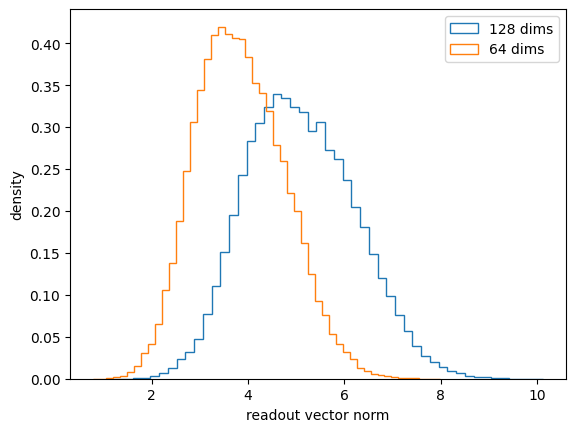

In [9]:
#normalized = (features - features.mean(axis=0)) / features.std(axis=0)
plt.hist(np.linalg.norm(features128, axis=1, ord=1), bins=50, histtype='step', density=True, label='128 dims')
plt.hist(np.linalg.norm(features64, axis=1, ord=1), bins=50, histtype='step', density=True, label='64 dims')
plt.ylabel('density')
plt.xlabel('readout vector norm')
plt.legend()
plt.savefig('plots/embedding_norms.png')
plt.show()

In [29]:
def visualize_cosine_sim(features, label, n=1000): 
    idcs = np.random.choice(features.shape[0], n)
    features = features[idcs]

    norm = torch.norm(features, dim=1)
    features = features / norm[:, None]
    cosine_sim = (
        (features[None, :, :] * features[:, None, :])
        .sum(dim=-1)
    )
    i, j = np.tril_indices(n, k=-1)
    cross_cos = cosine_sim[i, j]
    
    plt.hist(cross_cos, bins=50, histtype='step', density=True, label=label)

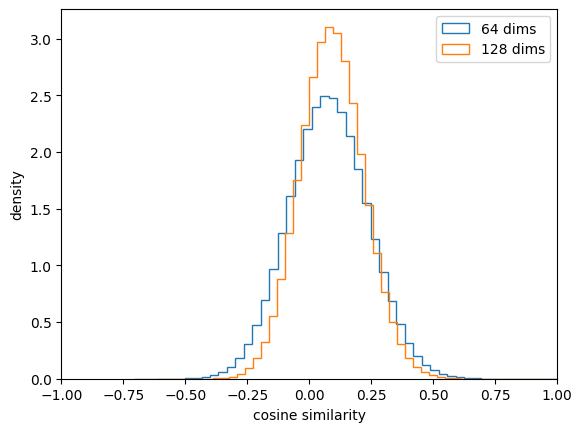

In [31]:
visualize_cosine_sim(features64, '64 dims', n=10000)
visualize_cosine_sim(features128, '128 dims', n=10000)
plt.xlabel('cosine similarity')
plt.ylabel('density')
plt.xlim(-1, 1)
plt.legend()
plt.savefig('plots/embedding_cosine_sim.png')
plt.show()

In [106]:
def visualize_gaussian_distances(n=1000, k=64):
    features = torch.randn((n, k))
    features = (
        features - features.mean(axis=0)
    ) / features.std(axis=0)
    dists = (
        (features[None, :, :] - features[:, None, :])
        .pow(2)
        .sum(axis=-1)
        .sqrt()
    )
    i, j = np.tril_indices(n, k=-1)
    unique_dists = dists[i, j]
    
    plt.hist(unique_dists, bins=100, histtype='step', label=features.shape[1], density=True)
    plt.xlabel('distance')
    plt.ylabel('density')
    print(f'std on {features.shape[1]}-dimensional features: {unique_dists.std()}')

std on 1-dimensional features: 0.8533328175544739
std on 2-dimensional features: 0.9263178706169128
std on 4-dimensional features: 0.963388979434967
std on 8-dimensional features: 0.9832839369773865
std on 16-dimensional features: 0.9973489046096802
std on 32-dimensional features: 1.0000945329666138
std on 64-dimensional features: 0.993370532989502
std on 128-dimensional features: 0.9991289973258972


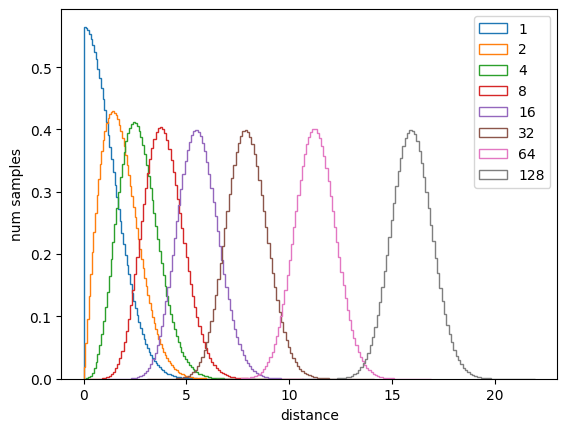

In [105]:
for k in [1, 2, 4, 8, 16, 32, 64, 128]:
    visualize_gaussian_distances(n=10000, k=k)
plt.legend()
plt.show()